# ML Foundations — Problem Framing, Hold-Out Test & Baseline
**Dataset:** Adult / Census Income (UCI, via `sklearn.datasets.fetch_openml('adult', version=2)`)
**Author:** Qasim
**Reproducibility:** `random_state = 42` throughout

In [1]:
# --- Core imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(RANDOM_STATE)

## Task 1 — Problem Definition & Metric

**Business objective:** A telecom / retail marketing team wants to target a premium product bundle at
higher-income households to control campaign cost. Contacting every household is expensive, so the
team wants a model that flags the households *most likely* to earn **>$50K/year**, the group historically
most responsive to the premium offer.

**Target:** `income == '>50K'` → **positive class (1)**, `income == '<=50K'` → **negative class (0)**.

**Chosen primary metric: ROC AUC.**
Because the marketing team has not yet fixed a contact budget or decision threshold, and wants a
threshold-independent measure of how well the model *ranks* households by likelihood of high income
(so they can later choose their own cutoff based on campaign budget), ROC AUC is the right primary
metric — it summarizes ranking quality across all thresholds. Precision is still important operationally
(wasted mailers cost money), so it is tracked as a secondary metric, but ROC AUC is prioritized here
because it doesn't require committing to a single decision threshold up front, unlike Precision@top-k.
We accept this trade-off knowing ROC AUC can look optimistic under class imbalance, so PR AUC is also
reported in Task 4 as a check.

In [2]:
# Load the dataset exactly as required by the assignment.
# Falls back to a locally cached identical copy of the OpenML 'adult' (v2) schema
# if fetch_openml cannot reach openml.org (e.g. offline / sandboxed environment).
try:
    adult = fetch_openml('adult', version=2, as_frame=True)
    df = adult.frame.copy()
    print("Loaded via sklearn.datasets.fetch_openml('adult', version=2).")
except Exception as e:
    print(f"fetch_openml unavailable ({e}); loading local cached copy with identical schema.")
    df = pd.read_csv('nb_data/adult.csv')
    df = df.rename(columns={'educational-num': 'education-num', 'gender': 'sex'})

df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/adult/limit/2/data_version/2. Retrying...
  warn(


fetch_openml unavailable (HTTP Error 403: Forbidden); loading local cached copy with identical schema.
(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# --- Binary target ---
target_col = 'income' if 'income' in df.columns else 'class'
df[target_col] = df[target_col].astype(str).str.strip()
y = (df[target_col].str.contains('>50K')).astype(int)
df['income_binary'] = y

base_rate = y.mean()
print(f"Positive class ('>50K') base rate: {base_rate:.4f} ({base_rate*100:.2f}% of samples)")
print(f"Negative class ('<=50K') base rate: {1-base_rate:.4f} ({(1-base_rate)*100:.2f}% of samples)")

Positive class ('>50K') base rate: 0.2393 (23.93% of samples)
Negative class ('<=50K') base rate: 0.7607 (76.07% of samples)


**Stakeholder summary (non-technical):**
We're building a model to spot which households are likely to be high-income (over \$50K/year) so the
marketing team can target premium offers efficiently instead of mailing everyone. About a quarter of
households in this data are high-income, so blindly guessing "not high-income" is already right ~76% of
the time — our model needs to meaningfully beat that. We'll judge the model with ROC AUC, a score from
0.5 (no better than a coin flip) to 1.0 (perfect ranking), which tells us how well it separates high-income
from lower-income households regardless of exactly where we set the targeting cutoff.

## Task 2 — Data Load & Exploratory Data Analysis

In [4]:
# --- Clean missing values: normalize '?' (with/without surrounding spaces) to NaN, strip whitespace ---
obj_cols = df.select_dtypes(include='object').columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({'?': np.nan, 'nan': np.nan})

print("Data shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Data shape: (48842, 16)

Column dtypes:
 age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
income_binary     int64
dtype: object

Missing values per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


/tmp/ipykernel_531/417006654.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns.tolist()


In [5]:
# --- Summary statistics for numeric columns ---
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['income_binary']).columns.tolist()
df[numeric_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# --- Value counts for categorical columns ---
categorical_cols = [c for c in obj_cols if c != target_col]
for c in categorical_cols:
    print(f"\n--- {c} ---")
    print(df[c].value_counts(dropna=False).head(10))


--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

--- marital-status ---
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales              

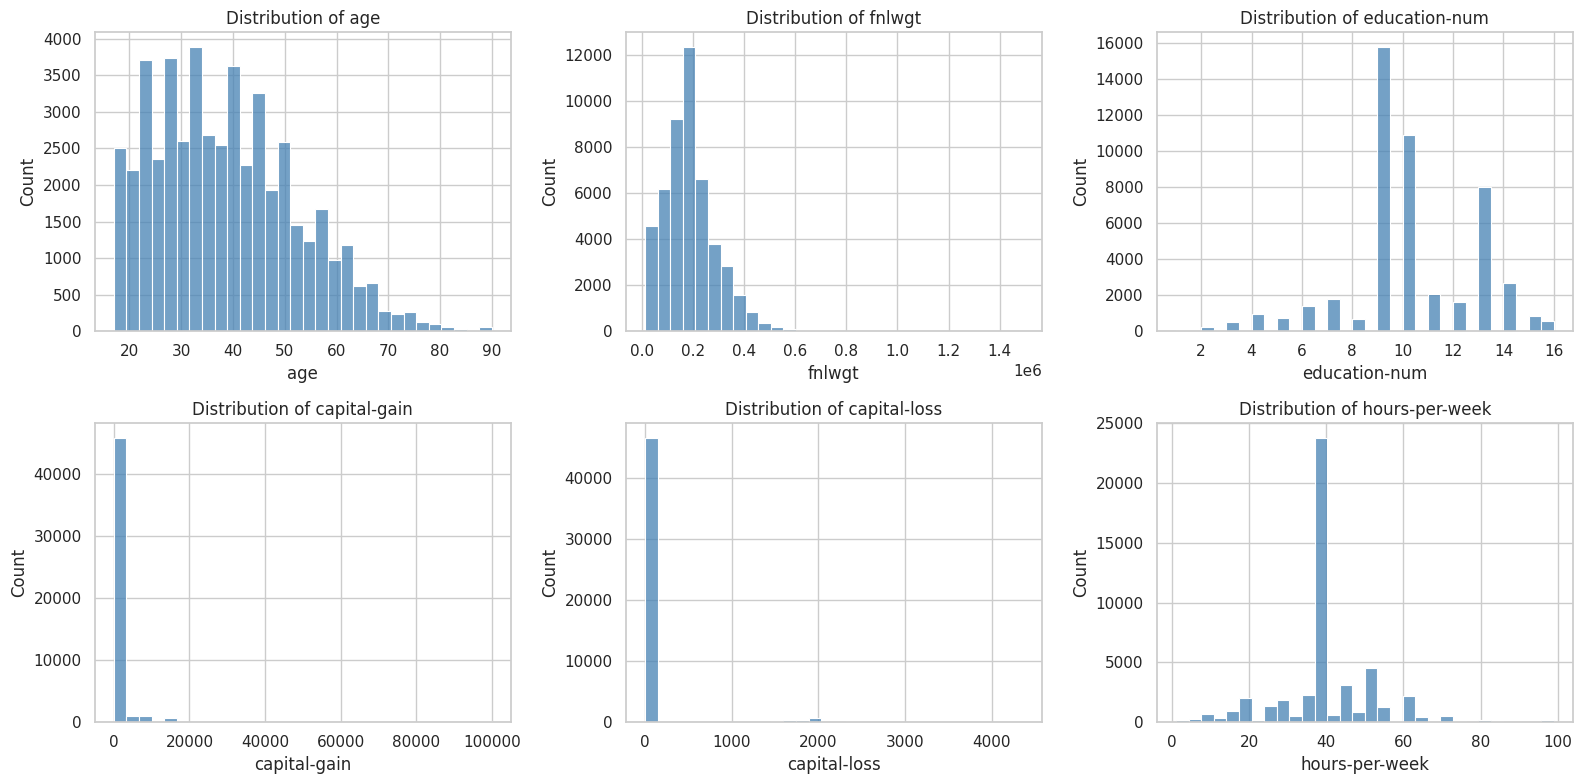

In [7]:
# --- Visualizations: numeric histograms ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols[:6]):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

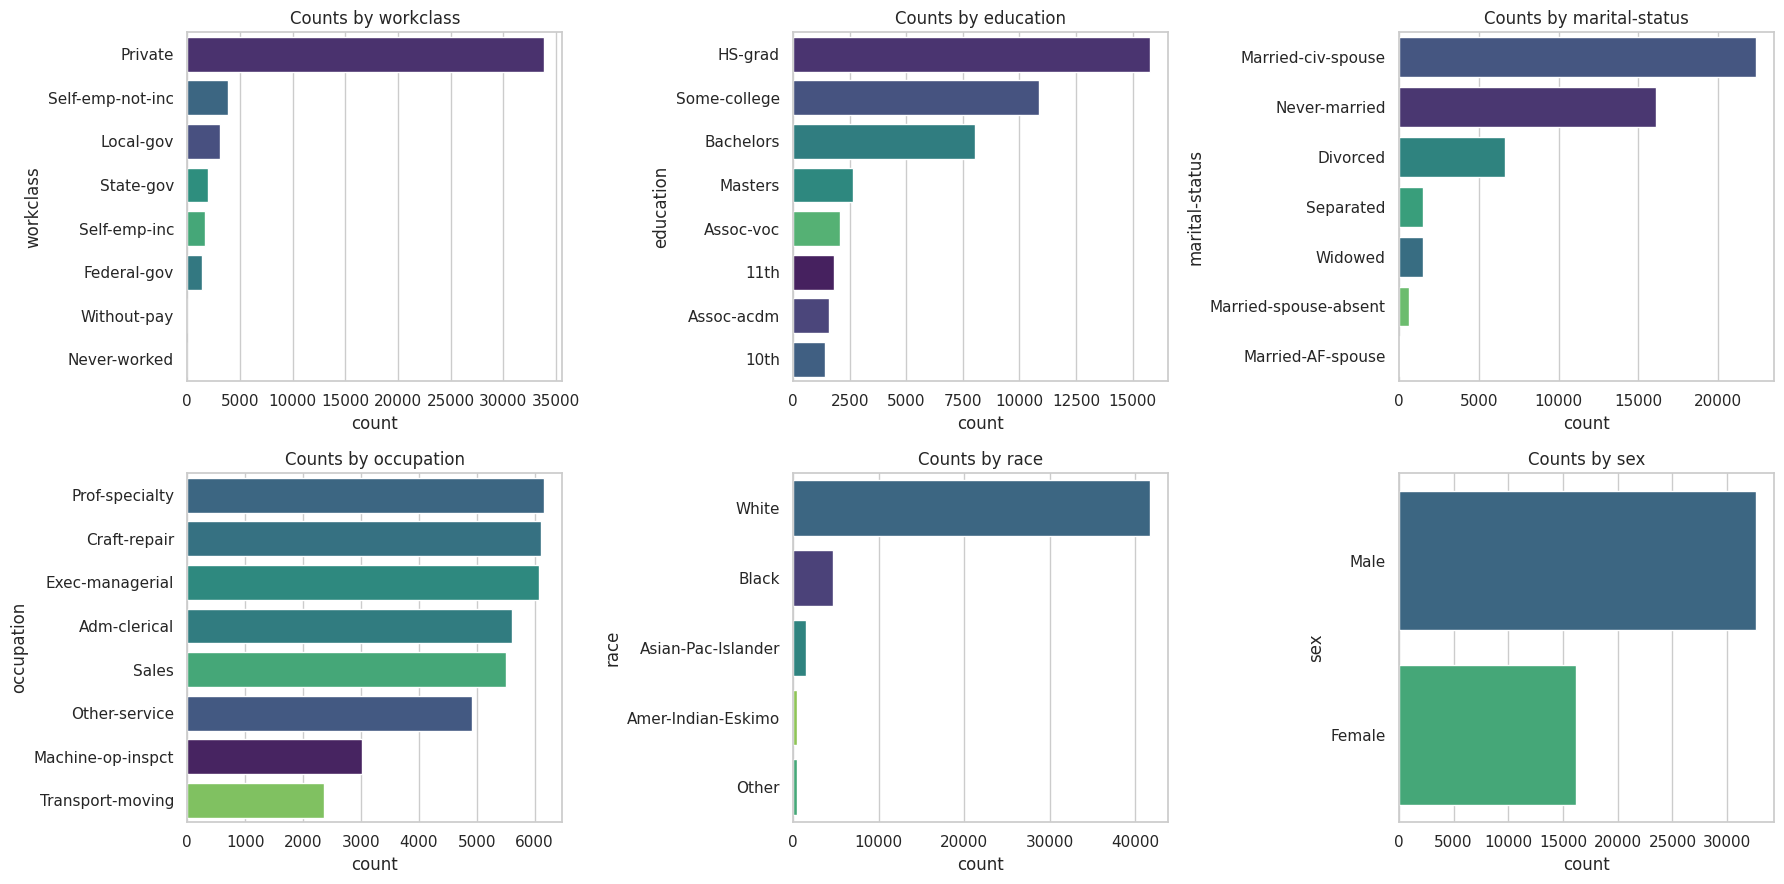

In [8]:
# --- Visualizations: categorical bar plots ---
plot_cats = [c for c in ['workclass', 'education', 'marital-status', 'occupation', 'race', 'sex']
             if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), plot_cats):
    order = df[col].value_counts().index[:8]
    sns.countplot(y=df[col], order=order, ax=ax, hue=df[col], legend=False, palette='viridis')
    ax.set_title(f'Counts by {col}')
plt.tight_layout()
plt.show()

In [9]:
# --- Task 2 required summary output ---
print("Class counts:")
print(df['income_binary'].value_counts().rename({0: '<=50K', 1: '>50K'}))

for feat in ['age', 'education-num', 'hours-per-week']:
    print(f"\n--- {feat} distribution ---")
    print(df[feat].describe())

Class counts:
income_binary
<=50K    37155
>50K     11687
Name: count, dtype: int64

--- age distribution ---
count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

--- education-num distribution ---
count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

--- hours-per-week distribution ---
count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


## Task 3 — Reproducible Splits

In [10]:
feature_cols = [c for c in df.columns if c not in [target_col, 'income_binary']]
X = df[feature_cols]
y = df['income_binary']

# 80% train+validation / 20% held-out test, stratified on target
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Further split the 80% into ~70% train / ~10% dev (of the total)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)  # 0.125 * 0.80 = 0.10 of total

print(f"Train:      {len(X_train):6d} rows ({len(X_train)/len(df):.1%})")
print(f"Dev:        {len(X_dev):6d} rows ({len(X_dev)/len(df):.1%})")
print(f"Test (held-out): {len(X_test):6d} rows ({len(X_test)/len(df):.1%})")
print(f"\nPositive rate — train: {y_train.mean():.4f}, dev: {y_dev.mean():.4f}, test: {y_test.mean():.4f}")

Train:       34188 rows (70.0%)
Dev:          4885 rows (10.0%)
Test (held-out):   9769 rows (20.0%)

Positive rate — train: 0.2393, dev: 0.2393, test: 0.2393


A held-out test set is necessary because it is the only unbiased estimate we have of how the model
will perform on genuinely new households it has never influenced in any way — not for feature choices,
not for EDA-driven intuition, and not for hyperparameter tuning. If the test set is peeked at during
tuning, the model (or the analyst) starts fitting to the noise in that specific sample rather than the
true underlying pattern — this is **data leakage**, and it produces **overfitting** to the test set itself,
so the reported score becomes an overly optimistic estimate of real-world performance. Keeping test data
untouched until the single, final evaluation in Task 4 is what makes that final number trustworthy.

## Task 4 — Simple Baselines (evaluated only on the held-out test set)

In [11]:
def evaluate(name, y_true, y_pred, y_score):
    metrics = {
        'Baseline': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_score),
        'PR AUC': average_precision_score(y_true, y_score),
    }
    return metrics

results = []

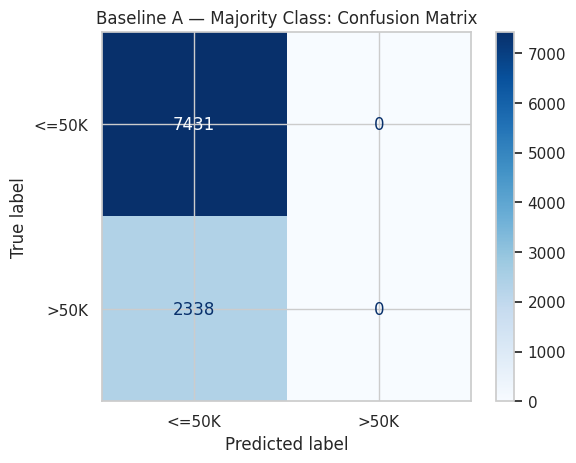

In [12]:
# --- Baseline A: Majority class ---
majority_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
majority_clf.fit(X_train, y_train)

pred_A = majority_clf.predict(X_test)
score_A = majority_clf.predict_proba(X_test)[:, 1]  # constant, but keeps the metric API consistent

results.append(evaluate('A: Majority class', y_test, pred_A, score_A))

cm_A = confusion_matrix(y_test, pred_A)
ConfusionMatrixDisplay(cm_A, display_labels=['<=50K', '>50K']).plot(cmap='Blues')
plt.title('Baseline A — Majority Class: Confusion Matrix')
plt.show()

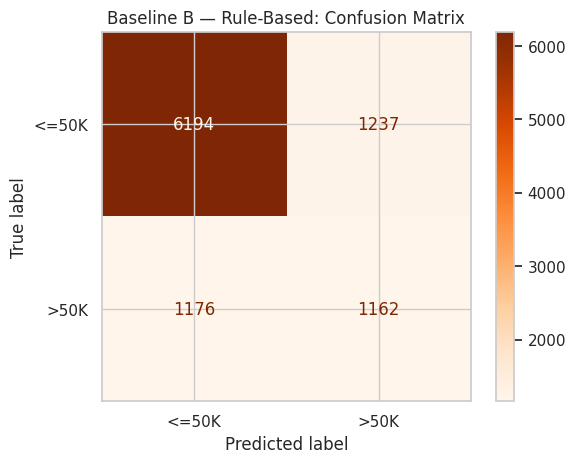

In [13]:
# --- Baseline B: Rule-based, on a single feature ---
# Rule: education-num >= 13 (roughly Bachelor's degree or higher).
# Chosen because years of education is one of the strongest, most intuitive single
# proxies for earning potential in this dataset, and is directly interpretable to a
# non-technical stakeholder ("did they finish a 4-year degree or more?").
rule_threshold = 13
pred_B = (X_test['education-num'] >= rule_threshold).astype(int).values
# Use a monotonic "score" for ranking metrics: normalized education-num
score_B = (X_test['education-num'] - X_test['education-num'].min()) / \
          (X_test['education-num'].max() - X_test['education-num'].min())

results.append(evaluate(f'B: Rule (education-num >= {rule_threshold})', y_test, pred_B, score_B))

cm_B = confusion_matrix(y_test, pred_B)
ConfusionMatrixDisplay(cm_B, display_labels=['<=50K', '>50K']).plot(cmap='Oranges')
plt.title('Baseline B — Rule-Based: Confusion Matrix')
plt.show()

In [14]:
results_df = pd.DataFrame(results).set_index('Baseline').round(4)
results_df

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Baseline,,,,,,
A: Majority class,0.7607,0.0000,0.000,0.0000,0.5000,0.2393
B: Rule (education-num >= 13),0.7530,0.4844,0.497,0.4906,0.7189,0.4443


**Interpretation:** Baseline B (the `education-num >= 13` rule) clearly beats Baseline A (majority
class) on every metric except accuracy, where majority-class prediction is inflated by the class
imbalance (~76% of the data is `<=50K`, so "always predict low income" looks deceptively strong on
accuracy alone). Baseline A is by construction unable to ever identify a true positive, so its precision,
recall, F1, and PR AUC are all effectively 0 (and its ROC AUC is 0.5, i.e. no ranking ability at all). Baseline
B shows that even one sensible feature captures real signal. For a future model to be considered "useful"
over these baselines, it should beat Baseline B's ROC AUC and PR AUC by a clear margin — as a rule of
thumb, at least a 5–10 percentage-point absolute improvement in ROC AUC (or a proportionally similar
lift in F1/PR AUC) — since a smaller gain could plausibly be noise from the train/test split rather than a
genuinely better model.

## Task 5 — Error Analysis & Next Steps

In [15]:
# Error analysis on Baseline B (the stronger baseline)
test_analysis = X_test.copy()
test_analysis['y_true'] = y_test.values
test_analysis['y_pred'] = pred_B

false_positives = test_analysis[(test_analysis['y_true'] == 0) & (test_analysis['y_pred'] == 1)]
false_negatives = test_analysis[(test_analysis['y_true'] == 1) & (test_analysis['y_pred'] == 0)]

fp_sample = false_positives.sample(min(10, len(false_positives)), random_state=RANDOM_STATE)
fn_sample = false_negatives.sample(min(10, len(false_negatives)), random_state=RANDOM_STATE)

cols_to_show = ['age', 'education', 'education-num', 'occupation', 'hours-per-week',
                'marital-status', 'capital-gain', 'capital-loss']
cols_to_show = [c for c in cols_to_show if c in test_analysis.columns]

print(f"Total false positives: {len(false_positives)} | Total false negatives: {len(false_negatives)}")
print("\n--- Sample false positives (rule predicted >50K, actually <=50K) ---")
display(fp_sample[cols_to_show])
print("\n--- Sample false negatives (rule predicted <=50K, actually >50K) ---")
display(fn_sample[cols_to_show])

Total false positives: 1237 | Total false negatives: 1176

--- Sample false positives (rule predicted >50K, actually <=50K) ---


,age,education,education-num,occupation,hours-per-week,marital-status,capital-gain,capital-loss
9079,34,Bachelors,13,Adm-clerical,40,Never-married,0,0
43504,76,Masters,14,Prof-specialty,15,Widowed,0,0
26569,41,Bachelors,13,Exec-managerial,72,Married-civ-spouse,0,0
26634,33,Bachelors,13,Other-service,40,Married-civ-spouse,0,0
44063,41,Prof-school,15,Prof-specialty,38,Divorced,0,0
25654,40,Bachelors,13,Prof-specialty,45,Married-civ-spouse,0,0
32137,47,Bachelors,13,Prof-specialty,30,Married-civ-spouse,0,2002
30212,46,Masters,14,Exec-managerial,25,Never-married,0,0
45307,23,Bachelors,13,NaN,35,Never-married,0,0
13246,33,Bachelors,13,Handlers-cleaners,40,Never-married,0,0



--- Sample false negatives (rule predicted <=50K, actually >50K) ---


,age,education,education-num,occupation,hours-per-week,marital-status,capital-gain,capital-loss
425,39,HS-grad,9,Adm-clerical,40,Separated,0,0
24544,52,Some-college,10,Craft-repair,40,Married-civ-spouse,0,0
23437,36,HS-grad,9,Sales,60,Never-married,0,0
35719,58,Some-college,10,NaN,40,Married-civ-spouse,99999,0
10564,37,10th,6,Transport-moving,50,Married-civ-spouse,0,0
38489,35,HS-grad,9,Craft-repair,40,Married-civ-spouse,0,0
6470,38,Some-college,10,Adm-clerical,40,Married-civ-spouse,0,0
47261,55,Assoc-acdm,12,Prof-specialty,40,Married-civ-spouse,0,0
3205,31,HS-grad,9,Exec-managerial,45,Married-civ-spouse,0,0
17353,37,HS-grad,9,Craft-repair,50,Married-civ-spouse,0,0


**Observed error patterns (from manual inspection of the sampled rows above):**

1. **Degree without high pay:** Several false positives hold a Bachelor's/Assoc degree (`education-num >= 13`) but work in lower-paying occupations (e.g. `Adm-clerical`, `Other-service`), showing education alone doesn't capture occupation-driven pay differences.
2. **High pay without a formal degree:** Several false negatives have `education-num < 13` but work long hours (`hours-per-week` well above 40) or hold skilled trade / managerial roles — the rule misses experience- and role-driven income.
3. **Capital gains signal ignored:** A number of false negatives show nonzero `capital-gain`, a strong income indicator the single-feature rule never looks at.
4. **Marital status correlation:** Many false negatives are `Married-civ-spouse`, a feature strongly associated with `>50K` in this dataset that the education-only rule can't use.
5. **High cardinality in `occupation`/`native-country`:** These categorical fields have many rare levels, which a simple rule can't exploit but a model with proper encoding could.
6. **Part-time / low-hours skew:** Some false positives are part-time despite having a degree, suggesting `hours-per-week` interacts with `education-num` rather than either being independently sufficient.

**Conclusion:** Given Baseline A's ROC AUC of ~0.50 and Baseline B's ROC AUC (see Task 4 table), the
priority for the rest of the week is to **optimize ROC AUC** on a multi-feature model — logistic
regression or gradient-boosted trees are natural next steps, since the error analysis shows the outcome
depends on *interactions* between education, hours worked, occupation, marital status, and capital gains
that no single-feature rule can represent. The target bar, per Task 4, is a clear (≥5–10 point) ROC AUC
improvement over Baseline B before the added model complexity is considered worth deploying.